In [2]:
import pandas as pd

def filtrar_estaciones_por_precipitacion(archivo_estaciones, archivo_precipitacion, archivo_salida):
    """
    Filtra un archivo de estaciones para que contenga solo aquellas presentes
    en un archivo de datos de precipitación y guarda el resultado.

    Args:
        archivo_estaciones (str): Ruta al archivo Excel con las columnas 'NOMBRE' y 'ALTITUD'.
        archivo_precipitacion (str): Ruta al archivo Excel con datos de precipitación,
                                     donde los nombres de las estaciones son las columnas.
        archivo_salida (str): Ruta donde se guardará el nuevo archivo Excel con los datos filtrados.
    """
    try:
        # --- Paso 1: Cargar los archivos de Excel en DataFrames de pandas ---
        # Se asume que la información está en la primera hoja de cada archivo.
        print("Cargando archivos de Excel...")
        df_estaciones = pd.read_excel(archivo_estaciones)
        df_precipitacion = pd.read_excel(archivo_precipitacion)
        print("Archivos cargados correctamente.")

        # --- Paso 2: Obtener la lista de nombres de estaciones del archivo de precipitación ---
        # Las columnas del archivo de precipitación son los nombres de las estaciones.
        # Excluimos la primera columna que contiene la 'Fecha'.
        nombres_estaciones_con_datos = df_precipitacion.columns[1:].tolist()
        print(f"\nSe encontraron {len(nombres_estaciones_con_datos)} estaciones con datos de precipitación.")
        # print("Estaciones encontradas:", nombres_estaciones_con_datos) # Descomentar para ver la lista

        # --- Paso 3: Filtrar el DataFrame de estaciones ---
        # Usamos el método `isin()` para seleccionar solo las filas cuyo 'NOMBRE'
        # se encuentre en nuestra lista de estaciones con datos.
        print("\nFiltrando las estaciones que tienen datos de precipitación...")
        df_filtrado = df_estaciones[df_estaciones['NOMBRE'].isin(nombres_estaciones_con_datos)].copy()

        # Opcional: Asegurarnos de que solo queden las columnas deseadas
        if 'NOMBRE' in df_filtrado.columns and 'ALTITUD' in df_filtrado.columns:
            df_final = df_filtrado[['NOMBRE', 'ALTITUD']]
        else:
            print("Advertencia: Las columnas 'NOMBRE' o 'ALTITUD' no se encontraron en el archivo de estaciones.")
            df_final = df_filtrado

        print(f"El filtrado resultó en {len(df_final)} estaciones.")

        # --- Paso 4: Guardar el resultado en un nuevo archivo de Excel ---
        # `index=False` evita que pandas añada una columna extra con el índice del DataFrame.
        df_final.to_excel(archivo_salida, index=False)
        print(f"\n¡Éxito! Los datos filtrados se han guardado en: '{archivo_salida}'")

        # --- Paso 5: Mostrar el resultado final ---
        print("\nVista previa de los datos filtrados:")
        print(df_final.head())


    except FileNotFoundError as e:
        print(f"Error: No se pudo encontrar el archivo. Por favor, revisa la ruta.\nDetalles: {e}")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


# --- CONFIGURACIÓN ---
# Por favor, reemplaza los siguientes nombres con las rutas exactas de tus archivos.
# Asegúrate de que los archivos estén en la misma carpeta que este script
# o proporciona la ruta completa (ej. "C:/Users/TuUsuario/Documents/archivo.xlsx").

nombre_archivo_estaciones = "estaciones_ideam/CNE_IDEAM.xls" # Archivo con columnas NOMBRE y ALTITUD
nombre_archivo_precipitacion = "datos_analisis/precipitacion_mensual_ideam.xlsx" # Archivo con columnas Fecha, ESTACION1, ESTACION2, etc.
nombre_archivo_salida = "estaciones_filtradas.xlsx" # Nombre del archivo que se creará

# --- EJECUCIÓN DEL SCRIPT ---
filtrar_estaciones_por_precipitacion(nombre_archivo_estaciones, nombre_archivo_precipitacion, nombre_archivo_salida)


Cargando archivos de Excel...
Archivos cargados correctamente.

Se encontraron 226 estaciones con datos de precipitación.

Filtrando las estaciones que tienen datos de precipitación...
El filtrado resultó en 214 estaciones.

¡Éxito! Los datos filtrados se han guardado en: 'estaciones_filtradas.xlsx'

Vista previa de los datos filtrados:
                               NOMBRE  ALTITUD
3282             EL TRUENO [31015010]      216
3283               GUAYARE [31090010]       95
3284  PUERTO INIRIDA - AUT [31095030]       98
3287           LA MARIPOSA [32010010]      285
3289           LA URIBE LA [32020020]      715


Procesando gráfico para 'Correlacion' vs 'ALTITUD'...


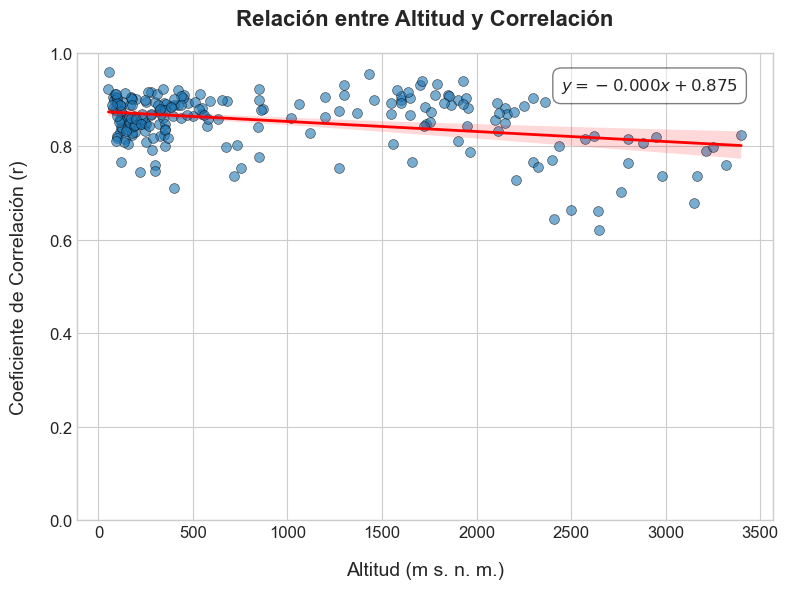

Gráfico guardado exitosamente como 'figuras/altitud_vs_correlacion.png'
Procesando gráfico para 'R2' vs 'ALTITUD'...


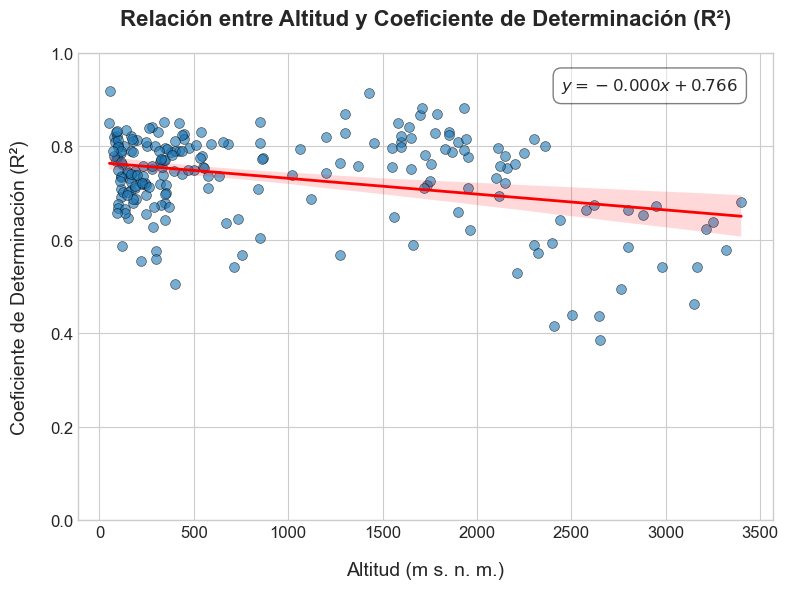

Gráfico guardado exitosamente como 'figuras/altitud_vs_r2.png'


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

def crear_grafico_dispersion_profesional(
    archivo_excel,
    col_x,
    col_y,
    titulo_grafico,
    etiqueta_x,
    etiqueta_y,
    nombre_archivo_salida
):
    """
    Crea un gráfico de dispersión de calidad de publicación con línea de regresión
    y su ecuación.

    Args:
        archivo_excel (str): Ruta al archivo Excel con los datos.
        col_x (str): Nombre de la columna para el eje X.
        col_y (str): Nombre de la columna para el eje Y.
        titulo_grafico (str): Título principal del gráfico.
        etiqueta_x (str): Etiqueta para el eje X.
        etiqueta_y (str): Etiqueta para el eje Y.
        nombre_archivo_salida (str): Nombre del archivo para guardar el gráfico (ej. 'grafico.png').
    """
    try:
        # --- 1. Cargar y preparar los datos ---
        print(f"Procesando gráfico para '{col_y}' vs '{col_x}'...")
        df = pd.read_excel(archivo_excel, engine='openpyxl')

        # Eliminar filas donde los valores de interés son nulos para evitar errores
        df_clean = df.dropna(subset=[col_x, col_y])
        x = df_clean[col_x]
        y = df_clean[col_y]

        if x.empty or y.empty:
            print(f"No hay datos suficientes para '{col_y}' vs '{col_x}' después de limpiar NaNs.")
            return

        # --- 2. Calcular la regresión lineal ---
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        # --- 3. Configurar el estilo del gráfico ---
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(8, 6))

        # --- 4. Crear el gráfico de dispersión y la línea de tendencia ---
        sns.regplot(
            x=x,
            y=y,
            ax=ax,
            scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k', 'linewidths': 0.5},
            line_kws={'color': 'red', 'linewidth': 2}
        )

        # --- 5. Formatear y añadir la ecuación al gráfico ---
        # MODIFICACIÓN: Se muestra solo la ecuación.
        ecuacion = f'$y = {slope:.3f}x + {intercept:.3f}$'
        
        # MODIFICACIÓN: Se posiciona el texto en la esquina superior derecha.
        ax.text(0.95, 0.95, ecuacion, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))

        # --- 6. Añadir títulos, etiquetas y ajustar ejes ---
        ax.set_title(titulo_grafico, fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel(etiqueta_x, fontsize=14, labelpad=15)
        ax.set_ylabel(etiqueta_y, fontsize=14, labelpad=15)
        ax.tick_params(axis='both', which='major', labelsize=12)
        
        # MODIFICACIÓN: Se establece el límite del eje Y de 0 a 1.
        ax.set_ylim(0, 1)

        # --- 7. Guardar y mostrar el gráfico ---
        plt.tight_layout()
        plt.savefig(nombre_archivo_salida, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Gráfico guardado exitosamente como '{nombre_archivo_salida}'")

    except FileNotFoundError:
        print(f"Error: No se pudo encontrar el archivo '{archivo_excel}'. Revisa la ruta y el nombre.")
    except KeyError as e:
        print(f"Error: La columna {e} no se encontró en el archivo Excel. Revisa los nombres de las columnas.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


# --- CONFIGURACIÓN ---
nombre_archivo_datos = "datos_analisis/altitud.xlsx"

# --- GENERAR GRÁFICO 1: ALTITUD vs CORRELACIÓN ---
crear_grafico_dispersion_profesional(
    archivo_excel=nombre_archivo_datos,
    col_x='ALTITUD',
    col_y='Correlacion',
    titulo_grafico='Relación entre Altitud y Correlación',
    etiqueta_x='Altitud (m s. n. m.)',
    etiqueta_y='Coeficiente de Correlación (r)',
    nombre_archivo_salida='figuras/altitud_vs_correlacion.png'
)

# --- GENERAR GRÁFICO 2: ALTITUD vs R2 ---
crear_grafico_dispersion_profesional(
    archivo_excel=nombre_archivo_datos,
    col_x='ALTITUD',
    col_y='R2',
    titulo_grafico='Relación entre Altitud y Coeficiente de Determinación (R²)',
    etiqueta_x='Altitud (m s. n. m.)',
    etiqueta_y='Coeficiente de Determinación (R²)',
    nombre_archivo_salida='figuras/altitud_vs_r2.png'
)


Cargando datos desde 'datos_analisis/altitud.xlsx'...
Procesando subplot 1: 'Correlacion' vs 'ALTITUD'...
Procesando subplot 2: 'R2' vs 'ALTITUD'...


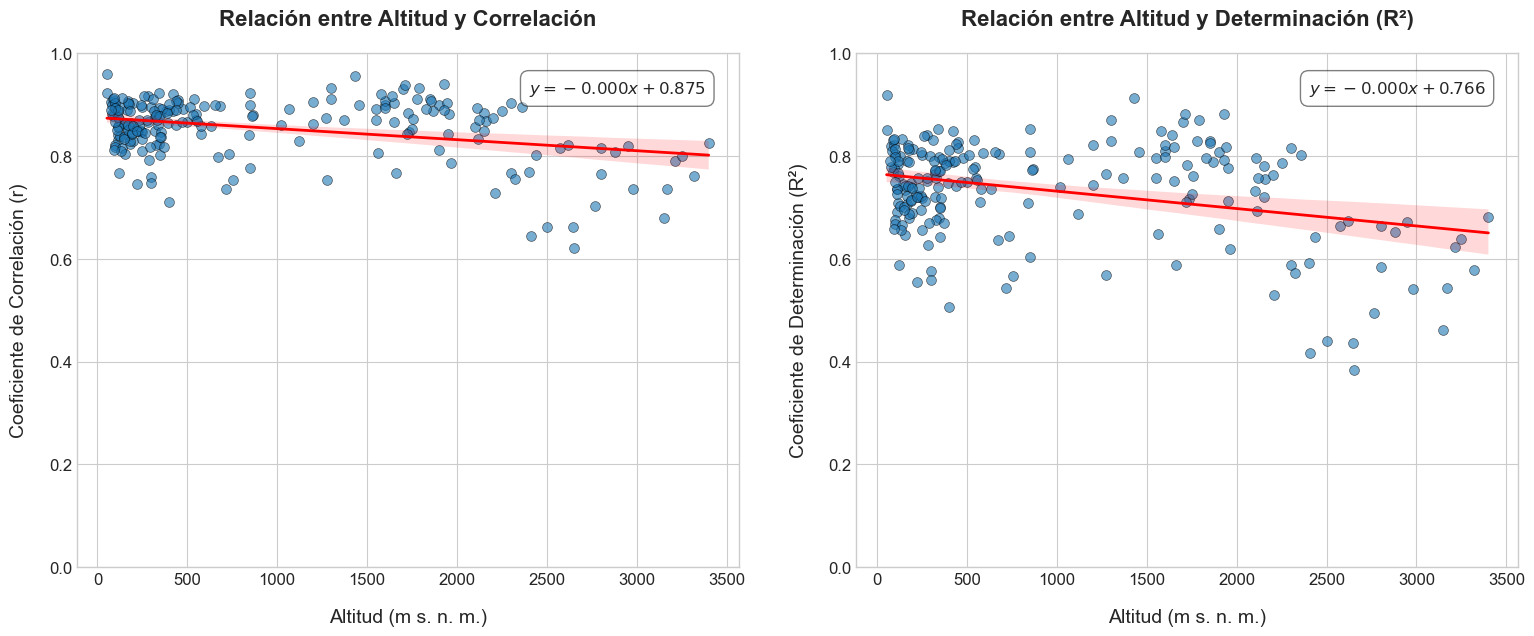

Figura guardada exitosamente como 'figuras/altitud_vs_correlacion_y_r2.png'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import os

def crear_grafico_subplots(
    archivo_excel,
    config_plot1,
    config_plot2,
    nombre_archivo_salida
):
    """
    Crea una figura con dos gráficos de dispersión en subplots (1 fila, 2 columnas).

    Args:
        archivo_excel (str): Ruta al archivo Excel con los datos.
        config_plot1 (dict): Diccionario con la configuración para el primer gráfico.
        config_plot2 (dict): Diccionario con la configuración para el segundo gráfico.
        nombre_archivo_salida (str): Nombre del archivo para guardar la figura.
    """
    try:
        # --- 1. Cargar los datos ---
        print(f"Cargando datos desde '{archivo_excel}'...")
        df = pd.read_excel(archivo_excel, engine='openpyxl')

        # --- 2. Configurar la figura y los subplots ---
        # Se crea una figura con 1 fila y 2 columnas para los gráficos.
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # 1 fila, 2 columnas. Tamaño ajustado.

        # Lista de configuraciones y ejes para iterar
        configs = [config_plot1, config_plot2]

        # --- 3. Generar cada gráfico en su subplot correspondiente ---
        for i, ax in enumerate(axes):
            config = configs[i]
            col_x = config['col_x']
            col_y = config['col_y']
            
            print(f"Procesando subplot {i+1}: '{col_y}' vs '{col_x}'...")

            # Preparar datos para el subplot actual
            df_clean = df.dropna(subset=[col_x, col_y])
            x = df_clean[col_x]
            y = df_clean[col_y]

            if x.empty or y.empty:
                print(f"No hay datos suficientes para el subplot {i+1}. Se omitirá.")
                ax.text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center')
                continue

            # Calcular la regresión lineal
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            # Crear el gráfico de dispersión en el eje (ax) actual
            sns.regplot(
                x=x,
                y=y,
                ax=ax,
                scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k', 'linewidths': 0.5},
                line_kws={'color': 'red', 'linewidth': 2}
            )

            # Formatear y añadir la ecuación
            ecuacion = f'$y = {slope:.3f}x + {intercept:.3f}$'
            ax.text(0.95, 0.95, ecuacion, transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))

            # Añadir títulos, etiquetas y ajustar ejes para el subplot actual
            ax.set_title(config['titulo_grafico'], fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel(config['etiqueta_x'], fontsize=14, labelpad=15)
            ax.set_ylabel(config['etiqueta_y'], fontsize=14, labelpad=15)
            ax.tick_params(axis='both', which='major', labelsize=12)
            ax.set_ylim(0, 1)

        # --- 4. Guardar y mostrar la figura completa ---
        plt.tight_layout(pad=3.0) # Ajusta el espaciado para que los títulos no se superpongan
        
        # Crear carpeta de salida si no existe
        output_dir = os.path.dirname(nombre_archivo_salida)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        plt.savefig(nombre_archivo_salida, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Figura guardada exitosamente como '{nombre_archivo_salida}'")

    except FileNotFoundError:
        print(f"Error: No se pudo encontrar el archivo '{archivo_excel}'. Revisa la ruta y el nombre.")
    except KeyError as e:
        print(f"Error: La columna {e} no se encontró en el archivo Excel. Revisa los nombres de las columnas.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


# --- CONFIGURACIÓN ---
nombre_archivo_datos = "datos_analisis/altitud.xlsx"

# Definir la configuración para el primer gráfico
configuracion1 = {
    'col_x': 'ALTITUD',
    'col_y': 'Correlacion',
    'titulo_grafico': 'Relación entre Altitud y Correlación',
    'etiqueta_x': 'Altitud (m s. n. m.)',
    'etiqueta_y': 'Coeficiente de Correlación (r)'
}

# Definir la configuración para el segundo gráfico
configuracion2 = {
    'col_x': 'ALTITUD',
    'col_y': 'R2',
    'titulo_grafico': 'Relación entre Altitud y Determinación (R²)',
    'etiqueta_x': 'Altitud (m s. n. m.)',
    'etiqueta_y': 'Coeficiente de Determinación (R²)'
}

# --- GENERAR LA FIGURA CON LOS DOS GRÁFICOS ---
crear_grafico_subplots(
    archivo_excel=nombre_archivo_datos,
    config_plot1=configuracion1,
    config_plot2=configuracion2,
    nombre_archivo_salida='figuras/altitud_vs_correlacion_y_r2.png'
)


Cargando datos desde 'datos_analisis/altitud.xlsx'...
Procesando subplot 1: 'Correlacion' vs 'ALTITUD'...
Procesando subplot 2: 'R2' vs 'ALTITUD'...


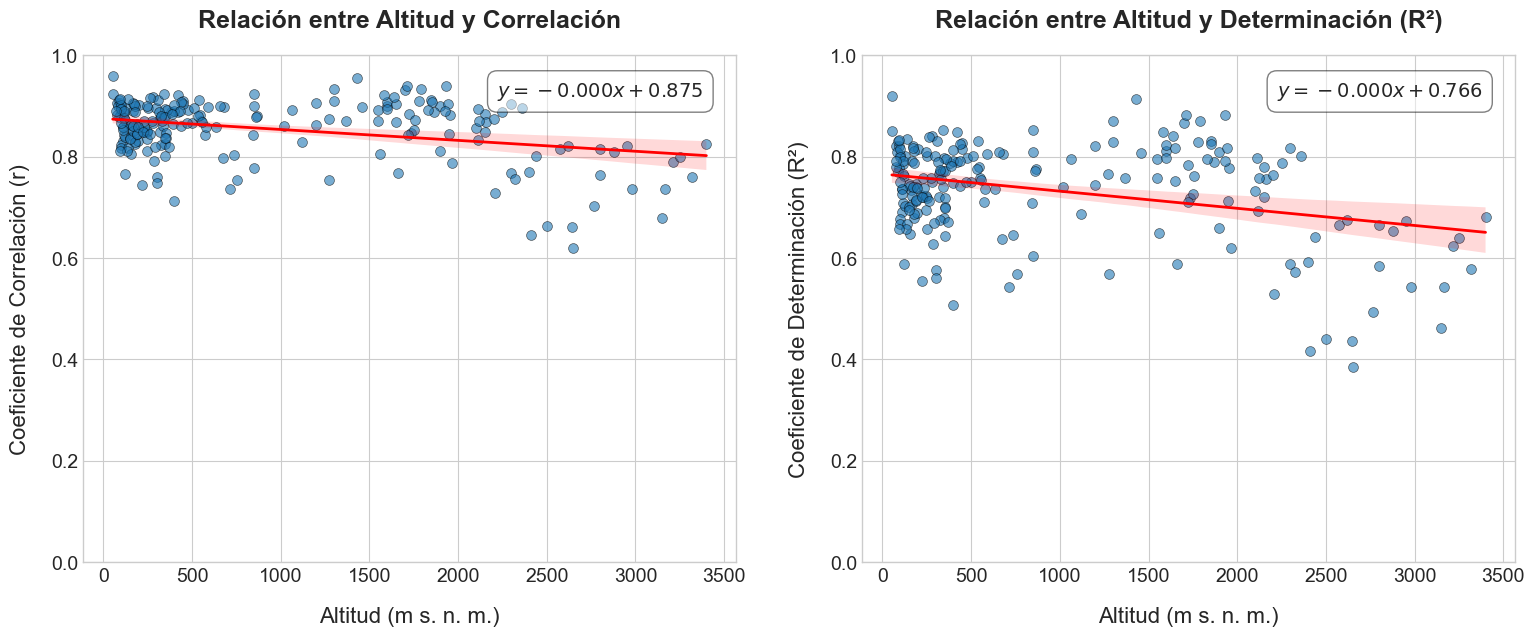

Figura guardada exitosamente como 'figuras/altitud_vs_correlacion_y_r2.png'


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import os

def crear_grafico_subplots(
    archivo_excel,
    config_plot1,
    config_plot2,
    nombre_archivo_salida
):
    """
    Crea una figura con dos gráficos de dispersión en subplots (1 fila, 2 columnas).

    Args:
        archivo_excel (str): Ruta al archivo Excel con los datos.
        config_plot1 (dict): Diccionario con la configuración para el primer gráfico.
        config_plot2 (dict): Diccionario con la configuración para el segundo gráfico.
        nombre_archivo_salida (str): Nombre del archivo para guardar la figura.
    """
    try:
        # --- 1. Cargar los datos ---
        print(f"Cargando datos desde '{archivo_excel}'...")
        df = pd.read_excel(archivo_excel, engine='openpyxl')

        # --- 2. Configurar la figura y los subplots ---
        # Se crea una figura con 1 fila y 2 columnas para los gráficos.
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # 1 fila, 2 columnas. Tamaño ajustado.

        # Lista de configuraciones y ejes para iterar
        configs = [config_plot1, config_plot2]

        # --- 3. Generar cada gráfico en su subplot correspondiente ---
        for i, ax in enumerate(axes):
            config = configs[i]
            col_x = config['col_x']
            col_y = config['col_y']
            
            print(f"Procesando subplot {i+1}: '{col_y}' vs '{col_x}'...")

            # Preparar datos para el subplot actual
            df_clean = df.dropna(subset=[col_x, col_y])
            x = df_clean[col_x]
            y = df_clean[col_y]

            if x.empty or y.empty:
                print(f"No hay datos suficientes para el subplot {i+1}. Se omitirá.")
                ax.text(0.5, 0.5, 'Datos insuficientes', ha='center', va='center')
                continue

            # Calcular la regresión lineal
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

            # Crear el gráfico de dispersión en el eje (ax) actual
            sns.regplot(
                x=x,
                y=y,
                ax=ax,
                scatter_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'k', 'linewidths': 0.5},
                line_kws={'color': 'red', 'linewidth': 2}
            )

            # Formatear y añadir la ecuación
            ecuacion = f'$y = {slope:.3f}x + {intercept:.3f}$'
            # MODIFICACIÓN: Aumentado el tamaño de la fuente de la ecuación
            ax.text(0.95, 0.95, ecuacion, transform=ax.transAxes, fontsize=14,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))

            # Añadir títulos, etiquetas y ajustar ejes para el subplot actual
            # MODIFICACIÓN: Aumentado el tamaño de la fuente del título
            ax.set_title(config['titulo_grafico'], fontsize=18, fontweight='bold', pad=20)
            # MODIFICACIÓN: Aumentado el tamaño de la fuente de las etiquetas de los ejes
            ax.set_xlabel(config['etiqueta_x'], fontsize=16, labelpad=15)
            ax.set_ylabel(config['etiqueta_y'], fontsize=16, labelpad=15)
            # MODIFICACIÓN: Aumentado el tamaño de la fuente de los números en los ejes
            ax.tick_params(axis='both', which='major', labelsize=14)
            ax.set_ylim(0, 1)

        # --- 4. Guardar y mostrar la figura completa ---
        plt.tight_layout(pad=3.0) # Ajusta el espaciado para que los títulos no se superpongan
        
        # Crear carpeta de salida si no existe
        output_dir = os.path.dirname(nombre_archivo_salida)
        if output_dir and not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        plt.savefig(nombre_archivo_salida, dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Figura guardada exitosamente como '{nombre_archivo_salida}'")

    except FileNotFoundError:
        print(f"Error: No se pudo encontrar el archivo '{archivo_excel}'. Revisa la ruta y el nombre.")
    except KeyError as e:
        print(f"Error: La columna {e} no se encontró en el archivo Excel. Revisa los nombres de las columnas.")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")


# --- CONFIGURACIÓN ---
nombre_archivo_datos = "datos_analisis/altitud.xlsx"

# Definir la configuración para el primer gráfico
configuracion1 = {
    'col_x': 'ALTITUD',
    'col_y': 'Correlacion',
    'titulo_grafico': 'Relación entre Altitud y Correlación',
    'etiqueta_x': 'Altitud (m s. n. m.)',
    'etiqueta_y': 'Coeficiente de Correlación (r)'
}

# Definir la configuración para el segundo gráfico
configuracion2 = {
    'col_x': 'ALTITUD',
    'col_y': 'R2',
    'titulo_grafico': 'Relación entre Altitud y Determinación (R²)',
    'etiqueta_x': 'Altitud (m s. n. m.)',
    'etiqueta_y': 'Coeficiente de Determinación (R²)'
}

# --- GENERAR LA FIGURA CON LOS DOS GRÁFICOS ---
crear_grafico_subplots(
    archivo_excel=nombre_archivo_datos,
    config_plot1=configuracion1,
    config_plot2=configuracion2,
    nombre_archivo_salida='figuras/altitud_vs_correlacion_y_r2.png'
)
